### ML with scikit-learn

In [1]:
import pandas as pd
import sklearn
print(sklearn.__version__)

1.6.1


In [2]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

## Blueprint of the process
1. Import the dataset and split the dataset into training and testing sets
2. Train the model
3. Test the model
4. Evaluate the model's performance

In [3]:
iris = load_iris()

iris_data = iris.data
iris_label = iris.target
print('iris target values:', iris_label)
print('iris target names:', iris.target_names)

iris_df = pd.DataFrame(data=iris_data, columns=iris.feature_names)
iris_df['label'] = iris.target
iris_df.head(3)

iris target values: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
iris target names: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0


In [4]:
X_train, X_test, y_train, y_test = train_test_split(iris_data, iris_label, 
                                                    test_size=0.2, random_state=11)

In [5]:
dt_clf = DecisionTreeClassifier(random_state=11)
dt_clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=11)

In [6]:
pred = dt_clf.predict(X_test)

In [7]:
from sklearn.metrics import accuracy_score
print('prediction accuracy: {0:.4f}'.format(accuracy_score(y_test, pred)))

prediction accuracy: 0.9333


### typical key of dataset of scikitlearn:
1. **data**: dataset of the feature e.g. 5.6, 3.3 ...
2. target: dataset of the label(answer) e.g. 0, 1 ...
3. target_names: names of each label e.g. setosa, versicolor ...
4. feature names: names of features e.g. sepal length, seplal width ... 
5. DESCR: description of the dataset and its features

In [8]:
from sklearn.datasets import load_iris

iris_data = load_iris()
print(type(iris_data))

<class 'sklearn.utils._bunch.Bunch'>


In [9]:
keys = iris_data.keys()
print('keys of iris dataset:\n', keys)

keys of iris dataset:
 dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [10]:
print('type of feature_names:', type(iris_data.feature_names))
print('shape of feature_names:', len(iris_data.feature_names))
print(iris_data.feature_names)

print('\ntype of target names:', type(iris_data.target_names))
print('shape of target names:', len(iris_data.target_names))
print(iris_data.target_names)

print('\ntype of data:', type(iris_data.data))
print('shape of data:', iris_data.data.shape)
print(iris_data.data[:5])

print('\ntype of target:', type(iris_data.target))
print('shape of target:', iris_data.target.shape)
print(iris_data.target[:5])

type of feature_names: <class 'list'>
shape of feature_names: 4
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

type of target names: <class 'numpy.ndarray'>
shape of target names: 3
['setosa' 'versicolor' 'virginica']

type of data: <class 'numpy.ndarray'>
shape of data: (150, 4)
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]

type of target: <class 'numpy.ndarray'>
shape of target: (150,)
[0 0 0 0 0]


In [11]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt_clf = DecisionTreeClassifier()
iris_data = load_iris()
train_data = iris_data.data
train_label = iris_data.target
dt_clf.fit(train_data, train_label)

pred = dt_clf.predict(train_data)
print('prediction accuracy: ', accuracy_score(train_label, pred))

prediction accuracy:  1.0


### Model Selection

In [12]:
# now.. let's try with train_test_split !

from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

dt_clf = DecisionTreeClassifier()
iris_data = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris_data.data, iris_data.target, 
                                                    test_size=0.3, random_state=121)

dt_clf.fit(X_train, y_train)
pred = dt_clf.predict(X_test)
print('prediction accuracy: {0:.4f}'.format(accuracy_score(y_test, pred)))

prediction accuracy: 0.9556


In [13]:
# now let's add cross validation to avoid overfitting to single test dataset

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
import numpy as np

features = iris.data
label = iris.target
dt_clf = DecisionTreeClassifier(random_state=156)
kfold = KFold(n_splits=5)
cv_accuracy = []

print('iris dataset shape:', iris_data.data.shape)

iris dataset shape: (150, 4)


In [14]:
n_iter = 0

for train_index, test_index in kfold.split(features):
    X_train, X_test = features[train_index], features[test_index]
    y_train, y_test = label[train_index], label[test_index]
    
    dt_clf.fit(X_train, y_train)
    pred = dt_clf.predict(X_test)
    n_iter += 1

    accuracy = np.round(accuracy_score(y_test, pred), 4)
    train_size = X_train.shape[0]
    test_size = X_test.shape[0]
    print('\n#{0} cross validation accuracy: {1}, train size: {2}, test size: {3}'.format(n_iter, accuracy, train_size, test_size))
    print('#{0} test set index: {1}'.format(n_iter, test_index))
    
    cv_accuracy.append(accuracy)

print('\n## average cross validation accuracy:', np.mean(cv_accuracy))


#1 cross validation accuracy: 1.0, train size: 120, test size: 30
#1 test set index: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29]

#2 cross validation accuracy: 0.9667, train size: 120, test size: 30
#2 test set index: [30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53
 54 55 56 57 58 59]

#3 cross validation accuracy: 0.8667, train size: 120, test size: 30
#3 test set index: [60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83
 84 85 86 87 88 89]

#4 cross validation accuracy: 0.9333, train size: 120, test size: 30
#4 test set index: [ 90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119]

#5 cross validation accuracy: 0.7333, train size: 120, test size: 30
#5 test set index: [120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137
 138 139 140 141 142 143 144 145 146 147 148 149]

## average cross validation accu

In [15]:
import pandas as pd

iris = load_iris()
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['label'] = iris.target
iris_df['label'].value_counts()

label
0    50
1    50
2    50
Name: count, dtype: int64

if the dataset is not balanced, it is necessary to use **stratified k-fold cross validation**

when using stratified k-fold cross validation, you need to specify the label of the dataset and add to the argument of the split function.

In [16]:
kfold = KFold(n_splits=3)
n_iter = 0
for train_index, test_index in kfold.split(iris_df):
    n_iter += 1
    label_train = iris_df['label'].iloc[train_index]
    label_test = iris_df['label'].iloc[test_index]
    print('## cross validation: {0}'.format(n_iter))
    print('#train set: \n{0}'.format(label_train.value_counts()))
    print('#test set: \n{0}'.format(label_test.value_counts()))    

## cross validation: 1
#train set: 
label
1    50
2    50
Name: count, dtype: int64
#test set: 
label
0    50
Name: count, dtype: int64
## cross validation: 2
#train set: 
label
0    50
2    50
Name: count, dtype: int64
#test set: 
label
1    50
Name: count, dtype: int64
## cross validation: 3
#train set: 
label
0    50
1    50
Name: count, dtype: int64
#test set: 
label
2    50
Name: count, dtype: int64


In [17]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=3)
n_iter = 0

for train_index, test_index in skf.split(iris_df, iris_df['label']):
    n_iter += 1
    label_train = iris_df['label'].iloc[train_index]
    label_test = iris_df['label'].iloc[test_index]
    print('## cross validation: {0}'.format(n_iter))
    print('#train set: \n{0}'.format(label_train.value_counts()))
    print('#test set: \n{0}'.format(label_test.value_counts()))

## cross validation: 1
#train set: 
label
2    34
0    33
1    33
Name: count, dtype: int64
#test set: 
label
0    17
1    17
2    16
Name: count, dtype: int64
## cross validation: 2
#train set: 
label
1    34
0    33
2    33
Name: count, dtype: int64
#test set: 
label
0    17
2    17
1    16
Name: count, dtype: int64
## cross validation: 3
#train set: 
label
0    34
1    33
2    33
Name: count, dtype: int64
#test set: 
label
1    17
2    17
0    16
Name: count, dtype: int64


In [18]:
from sklearn.model_selection import StratifiedKFold

dt_clf = DecisionTreeClassifier(random_state=156)

skfold = StratifiedKFold(n_splits=3)
n_iter = 0
cv_accuracy = []

for train_index, test_index in skfold.split(features, label):
    X_train, X_test = features[train_index], features[test_index]
    y_train, y_test = label[train_index], label[test_index]
    
    dt_clf.fit(X_train, y_train)
    pred = dt_clf.predict(X_test)
    
    n_iter += 1
    accuracy = np.round(accuracy_score(y_test, pred), 4)
    train_size = X_train.shape[0]
    test_size = X_test.shape[0]
    print('\n#{0} cross validation accuracy: {1}, train size: {2}, test size: {3}'.format(n_iter, accuracy, train_size, test_size))
    print('#{0} test set index: {1}'.format(n_iter, test_index))
    
    cv_accuracy.append(accuracy)

print('\n## accuracy of each fold:', np.round(cv_accuracy, 4))
print('## average cross validation accuracy:', np.round(np.mean(cv_accuracy), 4))


#1 cross validation accuracy: 0.98, train size: 100, test size: 50
#1 test set index: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  50
  51  52  53  54  55  56  57  58  59  60  61  62  63  64  65  66 100 101
 102 103 104 105 106 107 108 109 110 111 112 113 114 115]

#2 cross validation accuracy: 0.94, train size: 100, test size: 50
#2 test set index: [ 17  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  67
  68  69  70  71  72  73  74  75  76  77  78  79  80  81  82 116 117 118
 119 120 121 122 123 124 125 126 127 128 129 130 131 132]

#3 cross validation accuracy: 0.98, train size: 100, test size: 50
#3 test set index: [ 34  35  36  37  38  39  40  41  42  43  44  45  46  47  48  49  83  84
  85  86  87  88  89  90  91  92  93  94  95  96  97  98  99 133 134 135
 136 137 138 139 140 141 142 143 144 145 146 147 148 149]

## accuracy of each fold: [0.98 0.94 0.98]
## average cross validation accuracy: 0.9667


In [19]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.datasets import load_iris

iris_data = load_iris()
dt_clf = DecisionTreeClassifier(random_state=156)

data = iris_data.data
label = iris_data.target

scores = cross_val_score(dt_clf, data, label, scoring='accuracy', cv=3)
print('accuracy of each fold:', np.round(scores, 4))
print('average accuracy:', np.round(np.mean(scores), 4))

accuracy of each fold: [0.98 0.94 0.98]
average accuracy: 0.9667


While GridSearchCV helps you find the best parameters for the model, it takes longer time to run.

In [20]:
grid_parameters = {
                    'max_depth': [1, 2, 3], 
                    'min_samples_split': [2, 3]
                   }

In [21]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

iris_data = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris_data.data, iris_data.target, 
                                                    test_size=0.2, random_state=121)
dtree = DecisionTreeClassifier()

# param as dictionary
parameters = {'max_depth': [1, 2, 3], 'min_samples_split': [2, 3]}

In [22]:
import pandas as pd

grid_dtree = GridSearchCV(dtree, param_grid=parameters, cv=3)
grid_dtree.fit(X_train, y_train)

scores_df = pd.DataFrame(grid_dtree.cv_results_)
scores_df[['params', 'mean_test_score', 'rank_test_score',
           'split0_test_score', 'split1_test_score', 'split2_test_score']]

,params,mean_test_score,rank_test_score,split0_test_score,split1_test_score,split2_test_score
0,"{'max_depth': 1, 'min_samples_split': 2}",0.700000,5,0.700,0.7,0.70
1,"{'max_depth': 1, 'min_samples_split': 3}",0.700000,5,0.700,0.7,0.70
2,"{'max_depth': 2, 'min_samples_split': 2}",0.958333,3,0.925,1.0,0.95
3,"{'max_depth': 2, 'min_samples_split': 3}",0.958333,3,0.925,1.0,0.95
4,"{'max_depth': 3, 'min_samples_split': 2}",0.975000,1,0.975,1.0,0.95
5,"{'max_depth': 3, 'min_samples_split': 3}",0.975000,1,0.975,1.0,0.95


In [23]:
print('GridSearchCV best parameters:', grid_dtree.best_params_)
print('GridSearchCV best accuracy:{0:.4f}'.format(grid_dtree.best_score_))

GridSearchCV best parameters: {'max_depth': 3, 'min_samples_split': 2}
GridSearchCV best accuracy:0.9750


The best practice is to use GridSearchCV to find the best parameters for the model.
Then, use the best estimator to predict the test set separately.

In [24]:
estimator = grid_dtree.best_estimator_

pred = estimator.predict(X_test)
print('accuracy:{0:.4f}'.format(accuracy_score(y_test, pred)))

accuracy:0.9667


### Data Preprocessing

In [25]:
# label encoding

from sklearn.preprocessing import LabelEncoder

items = ['TV', '냉장고', '전자레인지', '컴퓨터', '선풍기', '선풍기', '믹서', '믹서']

encoder = LabelEncoder()
encoder.fit(items)
labels = encoder.transform(items)
print('encoding labels:', labels)

encoding labels: [0 1 4 5 3 3 2 2]


In [26]:
print('encoding labels:', encoder.classes_)

encoding labels: ['TV' '냉장고' '믹서' '선풍기' '전자레인지' '컴퓨터']


In [27]:
print('decoded labels:', encoder.inverse_transform(labels))

decoded labels: ['TV' '냉장고' '전자레인지' '컴퓨터' '선풍기' '선풍기' '믹서' '믹서']


In [28]:
# one-hot encoding

from sklearn.preprocessing import OneHotEncoder
import numpy as np

items = ['TV', '냉장고', '전자레인지', '컴퓨터', '선풍기', '선풍기', '믹서', '믹서']

items = np.array(items).reshape(-1, 1)

oh_encoder = OneHotEncoder()
oh_encoder.fit(items)
oh_labels = oh_encoder.transform(items)

print('one-hot encoding data')
print(oh_labels.toarray())
print('one-hot encoding data shape:', oh_labels.shape)

one-hot encoding data
[[1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]]
one-hot encoding data shape: (8, 6)


In [29]:
import pandas as pd

# easier one-hot encoding
df = pd.DataFrame({'item': ['TV', '냉장고', '전자레인지', '컴퓨터', '선풍기', '선풍기', '믹서', '믹서']})
# default dtype is bool
one_hot_encoded_df = pd.get_dummies(df, dtype=int)
print(one_hot_encoded_df.astype(int))

   item_TV  item_냉장고  item_믹서  item_선풍기  item_전자레인지  item_컴퓨터
0        1         0        0         0           0         0
1        0         1        0         0           0         0
2        0         0        0         0           1         0
3        0         0        0         0           0         1
4        0         0        0         1           0         0
5        0         0        0         1           0         0
6        0         0        1         0           0         0
7        0         0        1         0           0         0


feature scaling: standardization and normalization

$x_inew = \frac{x_i - \mu}{\sigma}$, $x_inew = \frac{x_i - min(x)}{max(x) - min(x)}$

In [30]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

print('mean of each feature:')
print(iris_df.mean())
print('\nstandard deviation of each feature:')
print(iris_df.std())


mean of each feature:
sepal length (cm)    5.843333
sepal width (cm)     3.057333
petal length (cm)    3.758000
petal width (cm)     1.199333
dtype: float64

standard deviation of each feature:
sepal length (cm)    0.828066
sepal width (cm)     0.435866
petal length (cm)    1.765298
petal width (cm)     0.762238
dtype: float64


In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(iris_df)
iris_scaled = scaler.transform(iris_df)

iris_df_scaled = pd.DataFrame(data=iris_scaled, columns=iris.feature_names)
print('mean of each feature:')
print(iris_df_scaled.mean())
print('\nstandard deviation of each feature:')
print(iris_df_scaled.std())
from sklearn.preprocessing import MinMaxScaler

mean of each feature:
sepal length (cm)   -1.690315e-15
sepal width (cm)    -1.842970e-15
petal length (cm)   -1.698641e-15
petal width (cm)    -1.409243e-15
dtype: float64

standard deviation of each feature:
sepal length (cm)    1.00335
sepal width (cm)     1.00335
petal length (cm)    1.00335
petal width (cm)     1.00335
dtype: float64


In [32]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(iris_df)
iris_scaled = scaler.transform(iris_df)

iris_df_scaled = pd.DataFrame(data=iris_scaled, columns=iris.feature_names)
print('minimum value of each feature:')
print(iris_df_scaled.min())
print('\nmaximum value of each feature:')
print(iris_df_scaled.max())


minimum value of each feature:
sepal length (cm)    0.0
sepal width (cm)     0.0
petal length (cm)    0.0
petal width (cm)     0.0
dtype: float64

maximum value of each feature:
sepal length (cm)    1.0
sepal width (cm)     1.0
petal length (cm)    1.0
petal width (cm)     1.0
dtype: float64


```
fit(): calculate the minimum and maximum value of the feature
transform(): scale the feature values
fit_transform(): fit and transform the feature values
```

1. it is better to fit and transform before splitting the dataset into training and testing sets.
2. if 1 is not possible, fit and transform the training set and transform the testing set. (DO NOT FIT seperately in the testing set)

In [33]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

train_array = np.arange(0,11).reshape(-1,1)
test_array = np.arange(0,6).reshape(-1,1)

scaler = MinMaxScaler()

scaler.fit(train_array)

train_scaled = scaler.transform(train_array)
print('original train array:', np.round(train_array.reshape(-1), 2))
print('scaled train array:', np.round(train_scaled.reshape(-1), 2))

original train array: [ 0  1  2  3  4  5  6  7  8  9 10]
scaled train array: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


In [34]:
scaler.fit(test_array)

test_scaled = scaler.transform(test_array)
print('original test array:', np.round(test_array.reshape(-1), 2))
print('scaled test array:', np.round(test_scaled.reshape(-1), 2))
# does not match the train scale

original test array: [0 1 2 3 4 5]
scaled test array: [0.  0.2 0.4 0.6 0.8 1. ]


In [35]:
scaler.fit(train_array)
test_scaled = scaler.transform(test_array)
print('original test array:', np.round(test_array.reshape(-1), 2))
print('scaled test array:', np.round(test_scaled.reshape(-1), 2))
# matches the train scale

original test array: [0 1 2 3 4 5]
scaled test array: [0.  0.1 0.2 0.3 0.4 0.5]


## Titanic Dataset

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [37]:
titanic_df = pd.read_csv('/mnt/c/Users/USER/Downloads/titanic/train.csv')
titanic_df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [38]:
print('\n ### Data Info ###')
print(titanic_df.info())


 ### Data Info ###
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [39]:
titanic_df['Age'] = titanic_df['Age'].fillna(titanic_df['Age'].mean())
titanic_df['Cabin'] = titanic_df['Cabin'].fillna('N')
titanic_df['Embarked'] = titanic_df['Embarked'].fillna('N')
print('dataset number of missing values', titanic_df.isnull().sum().sum())

dataset number of missing values 0


In [40]:
print('Sex values:', titanic_df['Sex'].value_counts())
print('\n Cabin values:', titanic_df['Cabin'].value_counts())
print('\n Embarked values:', titanic_df['Embarked'].value_counts())

Sex values: Sex
male      577
female    314
Name: count, dtype: int64

 Cabin values: Cabin
N              687
G6               4
C23 C25 C27      4
B96 B98          4
F2               3
              ... 
E17              1
A24              1
C50              1
B42              1
C148             1
Name: count, Length: 148, dtype: int64

 Embarked values: Embarked
S    644
C    168
Q     77
N      2
Name: count, dtype: int64


In [41]:
titanic_df['Cabin'] = titanic_df['Cabin'].str[:1]
print(titanic_df['Cabin'].head(3))

0    N
1    C
2    N
Name: Cabin, dtype: object


In [42]:
titanic_df.groupby(['Sex', 'Survived'])['Survived'].count()

Sex     Survived
female  0            81
        1           233
male    0           468
        1           109
Name: Survived, dtype: int64

<Axes: xlabel='Sex', ylabel='Survived'>

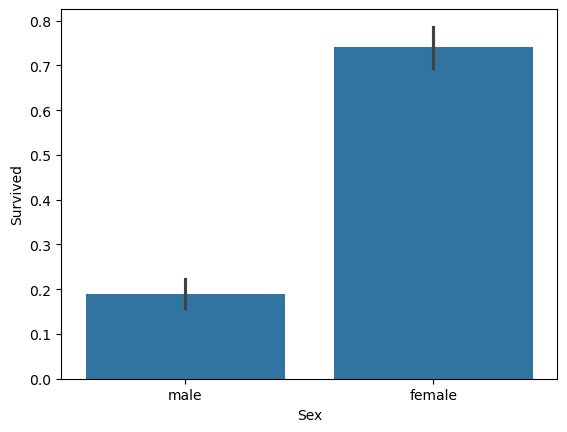

In [43]:
sns.barplot(x='Sex', y='Survived', data=titanic_df)

<Axes: xlabel='Pclass', ylabel='Survived'>

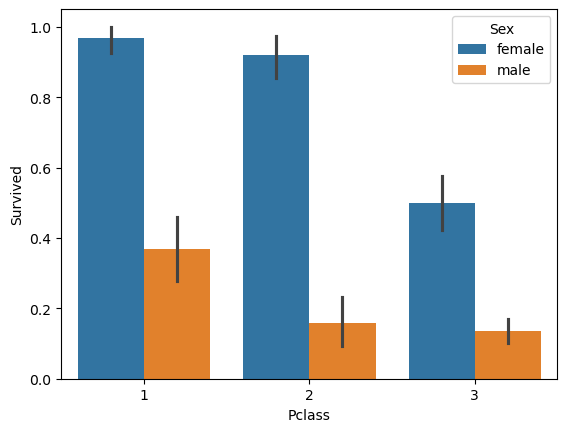

In [46]:
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=titanic_df)

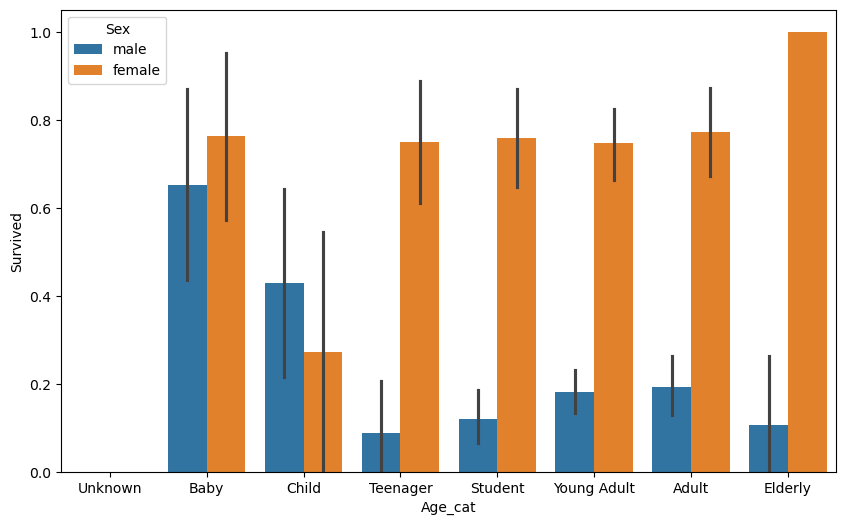

In [47]:
def get_category(age):
    cat = ''
    if age <= -1: cat = 'Unknown'
    elif age <= 5: cat = 'Baby'
    elif age <= 12: cat = 'Child'
    elif age <= 18: cat = 'Teenager'
    elif age <= 25: cat = 'Student'
    elif age <= 35: cat = 'Young Adult'
    elif age <= 60: cat = 'Adult'
    else: cat = 'Elderly'
    return cat
plt.figure(figsize=(10,6))

group_names = ['Unknown', 'Baby', 'Child', 'Teenager', 'Student', 'Young Adult', 'Adult', 'Elderly']

titanic_df['Age_cat'] = titanic_df['Age'].apply(lambda x: get_category(x))
sns.barplot(x='Age_cat', y='Survived', hue='Sex', data=titanic_df, order=group_names)
titanic_df.drop('Age_cat', axis=1, inplace=True)


In [50]:
from sklearn.preprocessing import LabelEncoder

def encode_features(df):
    features = ['Cabin', 'Sex', 'Embarked']
    for feature in features:
        le = LabelEncoder()
        le.fit(df[feature])
        df[feature] = le.transform(df[feature])
    return df

titanic_df = encode_features(titanic_df)
titanic_df_encoded = titanic_df[['Cabin', 'Sex', 'Embarked']]
titanic_df_encoded.head(3)

,Cabin,Sex,Embarked
0,7,1,3
1,2,0,0
2,7,0,3


In [57]:
def fillna(df):
    df['Age'] = df['Age'].fillna(df['Age'].mean())
    df['Cabin'] = df['Cabin'].fillna('N')
    df['Embarked'] = df['Embarked'].fillna('N')
    df['Fare'] = df['Fare'].fillna(0)
    return df

def drop_features(df):
    df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)
    return df

def format_features(df):
    df['Cabin'] = df['Cabin'].str[:1]
    features = ['Cabin', 'Sex', 'Embarked']
    for feature in features:
        le = LabelEncoder()
        le.fit(df[feature])
        df[feature] = le.transform(df[feature])
    return df

def transform_features(df):
    df = fillna(df)
    df = drop_features(df)
    df = format_features(df)
    return df

In [58]:
titanic_df = pd.read_csv('/mnt/c/Users/USER/Downloads/titanic/train.csv')
y_titanic_df = titanic_df['Survived']
X_titanic_df = titanic_df.drop('Survived', axis=1)

X_titanic_df = transform_features(X_titanic_df)

In [59]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_titanic_df, y_titanic_df, 
                                                    test_size=0.2, random_state=11)

In [60]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

dt_clf = DecisionTreeClassifier(random_state=11)
rf_clf = RandomForestClassifier(random_state=11)
lr_clf = LogisticRegression(solver='liblinear')

dt_clf.fit(X_train, y_train)
dt_pred = dt_clf.predict(X_test)
print('Decision Tree Accuracy: {0:.4f}'.format(accuracy_score(y_test, dt_pred)))

rf_clf.fit(X_train, y_train)
rf_pred = rf_clf.predict(X_test)
print('Random Forest Accuracy: {0:.4f}'.format(accuracy_score(y_test, rf_pred)))

lr_clf.fit(X_train, y_train)
lr_pred = lr_clf.predict(X_test)
print('Logistic Regression Accuracy: {0:.4f}'.format(accuracy_score(y_test, lr_pred)))

Decision Tree Accuracy: 0.7877
Random Forest Accuracy: 0.8547
Logistic Regression Accuracy: 0.8659


In [61]:
from sklearn.model_selection import KFold

def exec_kfold(clf, folds=5):
    kfold = KFold(n_splits=folds)
    scores = []

    for iter_count, (train_index, test_index) in enumerate(kfold.split(X_titanic_df)):
        X_train, X_test = X_titanic_df.values[train_index], X_titanic_df.values[test_index]
        y_train, y_test = y_titanic_df.values[train_index], y_titanic_df.values[test_index]

        clf.fit(X_train, y_train)
        pred = clf.predict(X_test)
        accuracy = accuracy_score(y_test, pred)
        scores.append(accuracy)
        print('{0} fold accuracy: {1:.4f}'.format(iter_count, accuracy))

    mean_score = np.mean(scores)
    print('average accuracy: {0:.4f}'.format(mean_score))

exec_kfold(dt_clf, folds=5)

0 fold accuracy: 0.7542
1 fold accuracy: 0.7809
2 fold accuracy: 0.7865
3 fold accuracy: 0.7697
4 fold accuracy: 0.8202
average accuracy: 0.7823


In [64]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(dt_clf, X_titanic_df, y_titanic_df, cv=5)

for iter_count, accuracy in enumerate(scores):
    print('{0} fold accuracy: {1:.4f}'.format(iter_count, accuracy))

print('average accuracy: {0:.4f}'.format(np.mean(scores)))

0 fold accuracy: 0.7430
1 fold accuracy: 0.7753
2 fold accuracy: 0.7921
3 fold accuracy: 0.7865
4 fold accuracy: 0.8427
average accuracy: 0.7879


In [65]:
from sklearn.model_selection import GridSearchCV

parameters = {'max_depth': [2, 3, 5, 10],
              'min_samples_split': [2, 3, 5],
              'min_samples_leaf': [1, 5, 8]}

grid_dclf = GridSearchCV(dt_clf, param_grid=parameters, scoring='accuracy', cv=5)
grid_dclf.fit(X_train, y_train)

print('GridSearchCV best parameters:', grid_dclf.best_params_)
print('GridSearchCV best accuracy: {0:.4f}'.format(grid_dclf.best_score_))

best_dclf = grid_dclf.best_estimator_

dpredictions = best_dclf.predict(X_test)

GridSearchCV best parameters: {'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 2}
GridSearchCV best accuracy: 0.7992
